In [6]:
import pandas as pd

In [1]:
import numpy as np

In [2]:

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [4]:
import os
os.getcwd()

'c:\\Users\\pc\\OneDrive\\Desktop\\python-telecom-churn\\src\\notebooks'

In [7]:
df = pd.read_csv("../../data/raw/telecom_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df = pd.read_csv("../../data/raw/telecom_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.shape

(7043, 21)

In [10]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


 Column Overview & Data Types

- The dataset consists of customer demographic, service usage, and billing information.
- Numerical features include tenure, monthly charges, and total charges.
- Categorical features represent contract type, payment method, and service subscriptions.
- The target variable Churn indicates whether a customer has left the service.

In [13]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [14]:
(df["Churn"].value_counts(normalize=True) * 100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

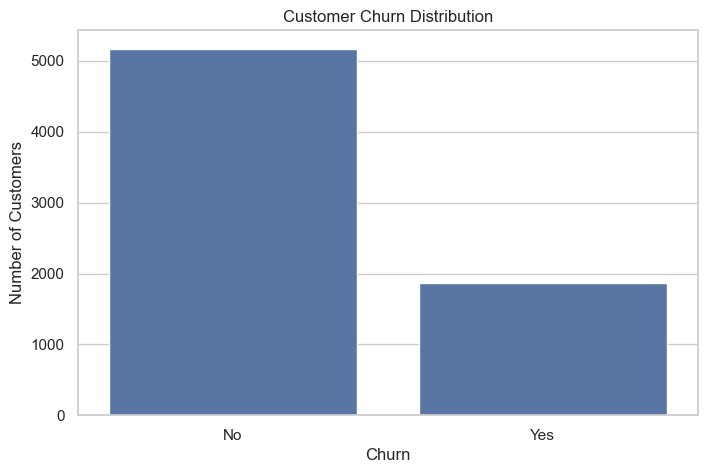

In [15]:
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

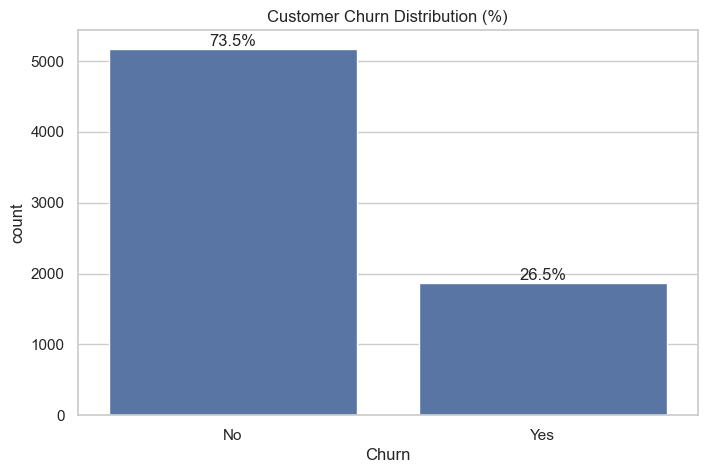

In [16]:
ax = sns.countplot(x="Churn", data=df)

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Customer Churn Distribution (%)")
plt.show()

 Churn Distribution Insight

- The dataset shows a noticeable imbalance between churned and retained customers.
- A significant percentage of customers have churned, indicating a clear retention challenge.
- This imbalance should be considered in modeling and evaluation stages.

In [17]:
df["MonthlyCharges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

Boxplot

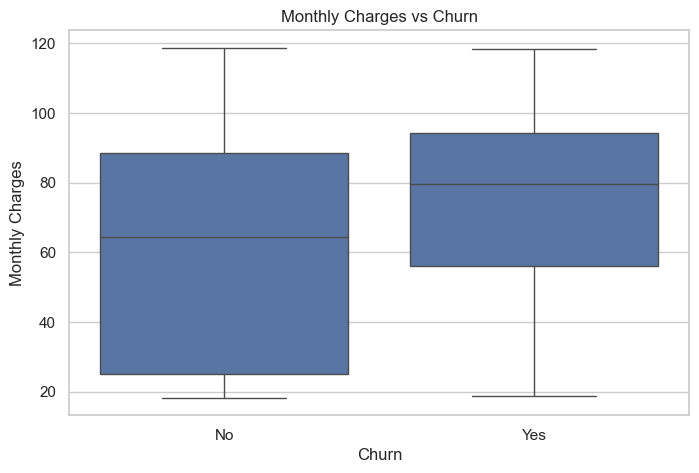

In [18]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

Compare averages

In [19]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

 Monthly Charges vs Churn Insight

- Customers who churn tend to have higher monthly charges compared to retained customers.
- This suggests that pricing or perceived value may influence churn decisions.
- High-cost customers may require targeted retention strategies such as discounts or personalized plans.

Do new customers churn more than long-term customers?

In [20]:
df["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

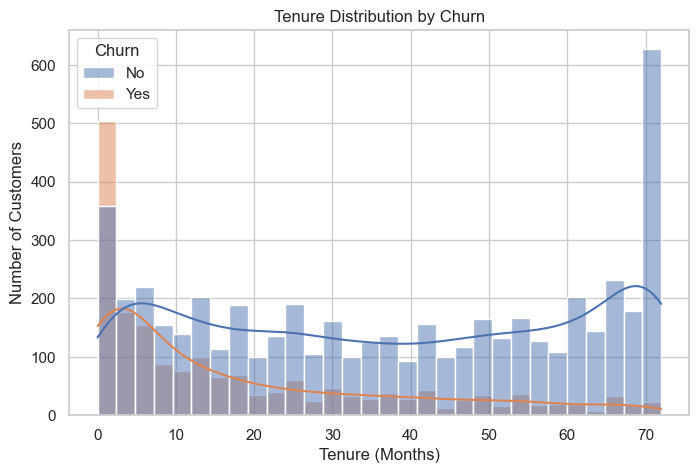

In [21]:
sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

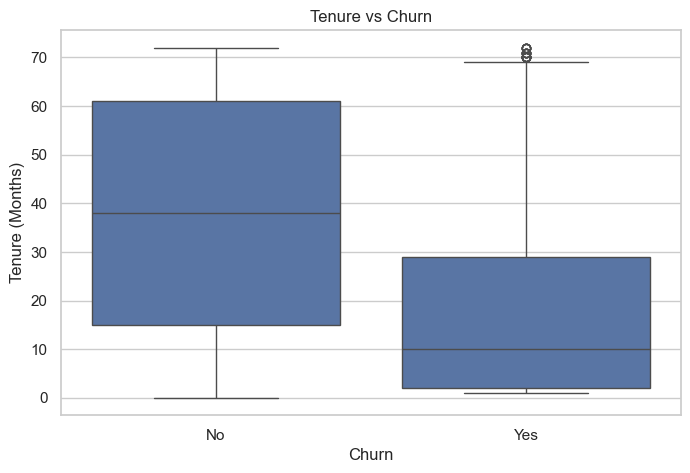

In [22]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

In [23]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

Tenure vs Churn Insight

- Customers with shorter tenure are significantly more likely to churn.
- Long-term customers show much lower churn rates, indicating stronger loyalty.
- The first few months of customer onboarding are critical for retention.

In [24]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [25]:
contract_churn = df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack()
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


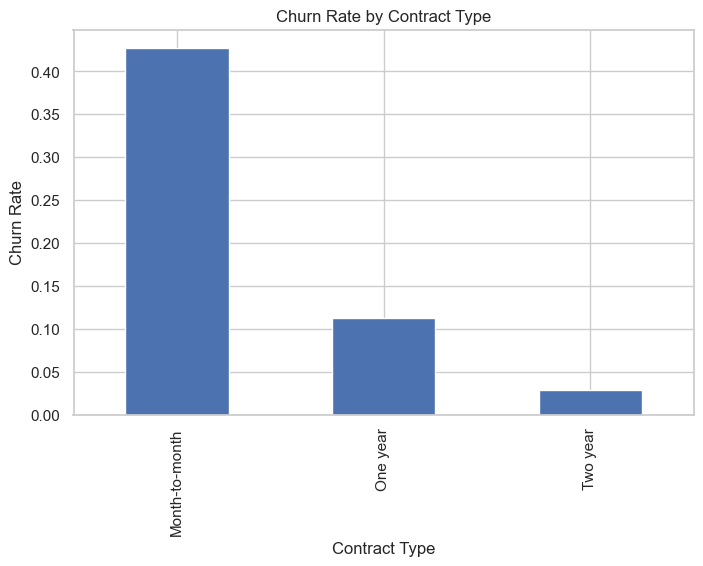

In [26]:
contract_churn["Yes"].sort_values(ascending=False).plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract Type")
plt.show()

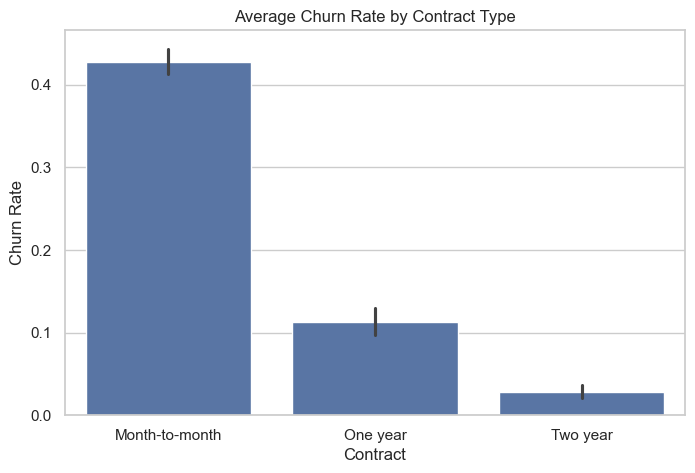

In [27]:
sns.barplot(
    x="Contract",
    y=df["Churn"].eq("Yes").astype(int),
    data=df
)
plt.title("Average Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.show()

 Contract Type vs Churn Insight

- Customers on month-to-month contracts have the highest churn rate.
- Long-term contracts (one-year and two-year) significantly reduce churn.
- Encouraging customers to move to longer contracts can improve retention.

In [28]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

In [29]:
corr = df[num_cols + ["Churn"]].copy()
corr["Churn"] = corr["Churn"].map({"Yes": 1, "No": 0})
corr_matrix = corr.corr()
corr_matrix

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000000,0.247900,0.825880,-0.352229
MonthlyCharges,0.247900,1.000000,0.651065,0.193356
TotalCharges,0.825880,0.651065,1.000000,-0.199484
Churn,-0.352229,0.193356,-0.199484,1.000000


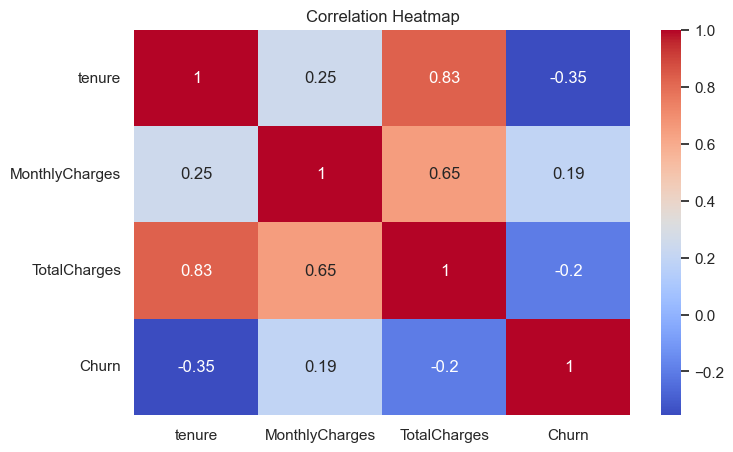

In [30]:
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

 Correlation Analysis Insight

- Tenure has a strong negative correlation with churn.
- Monthly charges show a positive relationship with churn.
- Total charges are closely related to tenure, indicating long-term customer value.

 Key Business Insights from Telecom Churn Analysis

1. Overall Churn Behavior
- A significant portion of customers have churned, indicating a clear retention challenge.
- Churn is not evenly distributed and shows identifiable patterns.

 2. Pricing Impact
- Customers with higher monthly charges are more likely to churn.
- This suggests price sensitivity and potential dissatisfaction with perceived value.

 3. Customer Tenure
- Customers with shorter tenure exhibit significantly higher churn.
- Early-stage customer engagement is critical to long-term retention.

 4. Contract Structure
- Month-to-month contracts have the highest churn rate.
- Long-term contracts (1-year and 2-year) significantly reduce churn risk.

 5. Key Drivers of Churn
Based on the analysis, the main drivers of churn appear to be:
- Short customer tenure
- High monthly charges
- Flexible (month-to-month) contract types

 6. Business Recommendations
- Strengthen onboarding programs for new customers.
- Offer incentives to shift customers to long-term contracts.
- Introduce targeted pricing or loyalty discounts for high-risk customers.

In [31]:
# Create processed directory if it doesn't exist
import os

processed_path = "../../data/processed"
os.makedirs(processed_path, exist_ok=True)

# Save final dataset
df.to_csv(f"{processed_path}/telecom_churn_eda_ready.csv", index=False)